In [2]:
!pip install causal-learn networkx matplotlib

Đang chạy thuật toán PC để tìm đồ thị nhân quả...


Depth=4, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 1160.04it/s]


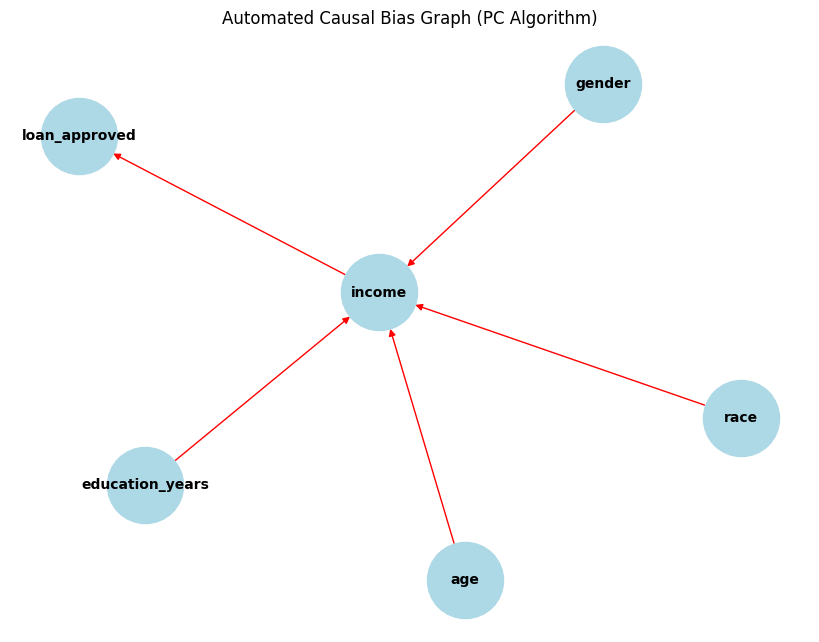


--- KẾT QUẢ KHÁM PHÁ BIAS PATHWAYS ---
⚠️ CẢNH BÁO: Phát hiện đường dẫn thiên kiến từ 'gender' đến 'loan_approved':
gender -> income -> loan_approved
⚠️ CẢNH BÁO: Phát hiện đường dẫn thiên kiến từ 'race' đến 'loan_approved':
race -> income -> loan_approved


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo không quan trọng

# 1. Đọc dữ liệu và lấy mẫu để thuật toán chạy nhanh
df = pd.read_csv('../data/synthetic_intersectional_data.csv')
df_sample = df.sample(10000, random_state=42).copy()

# 2. Mã hóa biến phân loại (Categorical to Numeric)
le = LabelEncoder()
df_sample['gender'] = le.fit_transform(df_sample['gender'])
df_sample['race'] = le.fit_transform(df_sample['race'])

data = df_sample.to_numpy()
node_names = df_sample.columns.tolist()

# 3. Chạy thuật toán PC
print("Đang chạy thuật toán PC để tìm đồ thị nhân quả...")
cg = pc(data, 0.05, "fisherz", node_names=node_names)

# 4. Trực quan hóa Đồ thị Nhân quả (Causal Graph)
adj_matrix = cg.G.graph
G = nx.DiGraph()
for node in node_names:
    G.add_node(node)

# Trích xuất các cạnh có hướng (i -> j)
for i in range(len(node_names)):
    for j in range(len(node_names)):
        if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
            G.add_edge(node_names[i], node_names[j])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

# ĐÃ SỬA: 'lightblue' không còn dấu #
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='red', 
        node_size=3000, font_size=10, font_weight='bold', arrows=True)
plt.title("Automated Causal Bias Graph (PC Algorithm)")
plt.show()

# 5. Tự động phát hiện Bias Pathways
print("\n--- KẾT QUẢ KHÁM PHÁ BIAS PATHWAYS ---")
sensitive_attrs = ['gender', 'race']
target = 'loan_approved'

for attr in sensitive_attrs:
    if nx.has_path(G, attr, target):
        paths = list(nx.all_simple_paths(G, source=attr, target=target))
        print(f"⚠️ CẢNH BÁO: Phát hiện đường dẫn thiên kiến từ '{attr}' đến '{target}':")
        for p in paths:
            print(" -> ".join(p))
    else:
        print(f"✅ An toàn: Không có đường dẫn thiên kiến từ '{attr}' đến '{target}'")


Đang phân tích: ../data/german_credit_processed.csv
Đang chạy thuật toán PC...


Depth=2, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 984.96it/s] 


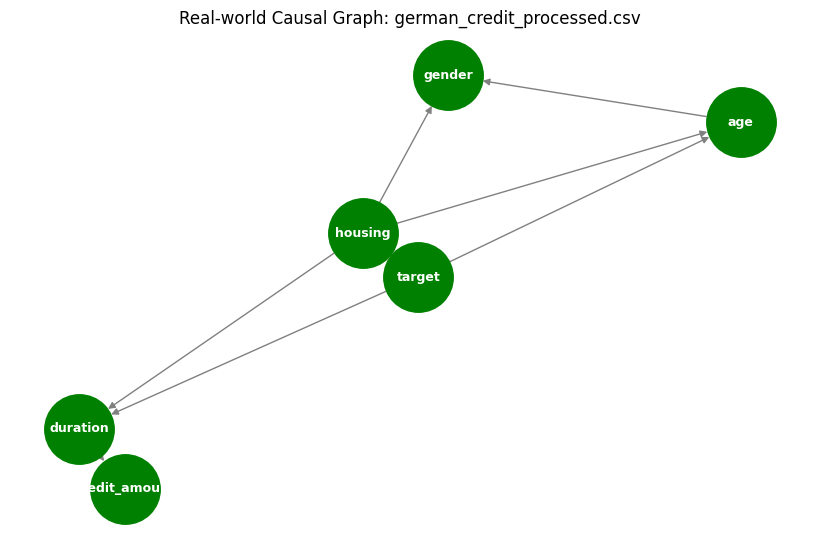

✅ An toàn: Không có đường dẫn thiên kiến trực tiếp/gián tiếp từ 'gender' đến 'target'
✅ An toàn: Không có đường dẫn thiên kiến trực tiếp/gián tiếp từ 'age' đến 'target'

Đang phân tích: ../data/home_credit_processed.csv
Đang chạy thuật toán PC...


Depth=3, working on node 4: 100%|██████████| 5/5 [00:00<00:00, 861.04it/s] 


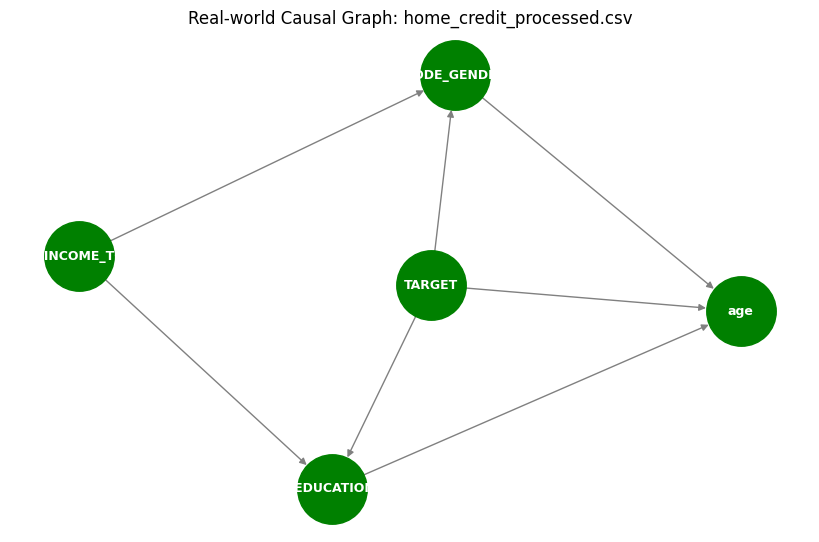

✅ An toàn: Không có đường dẫn thiên kiến trực tiếp/gián tiếp từ 'CODE_GENDER' đến 'TARGET'
✅ An toàn: Không có đường dẫn thiên kiến trực tiếp/gián tiếp từ 'age' đến 'TARGET'


In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

def discover_real_world_bias(csv_path, subset_cols, sensitive_attrs, target_col):
    print(f"\n{'='*50}\nĐang phân tích: {csv_path}\n{'='*50}")
    
    # Đọc dữ liệu và xóa NaN ngay từ đầu
    df = pd.read_csv(csv_path)[subset_cols].dropna()
    df_sample = df.sample(n=min(5000, len(df)), random_state=42).copy()
    
    # Mã hóa AN TOÀN TỐI ĐA: Bất kỳ cột nào KHÔNG phải là số đều bị ép sang số
    le = LabelEncoder()
    for col in df_sample.columns:
        if not pd.api.types.is_numeric_dtype(df_sample[col]):
            df_sample[col] = le.fit_transform(df_sample[col].astype(str))
            
    # Đảm bảo dữ liệu là numpy array định dạng float64 chuẩn
    data = np.asarray(df_sample, dtype=np.float64)
    node_names = df_sample.columns.tolist()
    
    # Chạy thuật toán PC
    print("Đang chạy thuật toán PC...")
    cg = pc(data, 0.05, "fisherz", node_names=node_names)
    
    # Trực quan hóa đồ thị
    adj_matrix = cg.G.graph
    G = nx.DiGraph()
    for node in node_names:
        G.add_node(node)
        
    for i in range(len(node_names)):
        for j in range(len(node_names)):
            if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                G.add_edge(node_names[i], node_names[j])
                
    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='green', edge_color='gray', 
            node_size=2500, font_size=9, font_weight='bold', arrows=True, font_color='white')
    plt.title(f"Real-world Causal Graph: {csv_path.split('/')[-1]}")
    plt.show()
    
    # In ra Bias Pathways
    for attr in sensitive_attrs:
        if attr in G.nodes and target_col in G.nodes:
            if nx.has_path(G, attr, target_col):
                paths = list(nx.all_simple_paths(G, source=attr, target=target_col))
                print(f"⚠️ Phát hiện thiên kiến từ '{attr}' đến '{target_col}':")
                for p in paths:
                    print(" -> ".join(p))
            else:
                print(f"✅ An toàn: Không có đường dẫn thiên kiến trực tiếp/gián tiếp từ '{attr}' đến '{target_col}'")

# 1. Phân tích German Credit
german_cols = ['gender', 'age', 'credit_amount', 'duration', 'housing', 'target']
discover_real_world_bias('../data/german_credit_processed.csv', german_cols, ['gender', 'age'], 'target')

# 2. Phân tích Home Credit
home_cols = ['CODE_GENDER', 'age', 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL', 'TARGET']
discover_real_world_bias('../data/home_credit_processed.csv', home_cols, ['CODE_GENDER', 'age'], 'TARGET')

Đang chuẩn bị dữ liệu cho GES (Score-based)...
Đang chạy thuật toán GES (Tối ưu hóa điểm số BIC)...


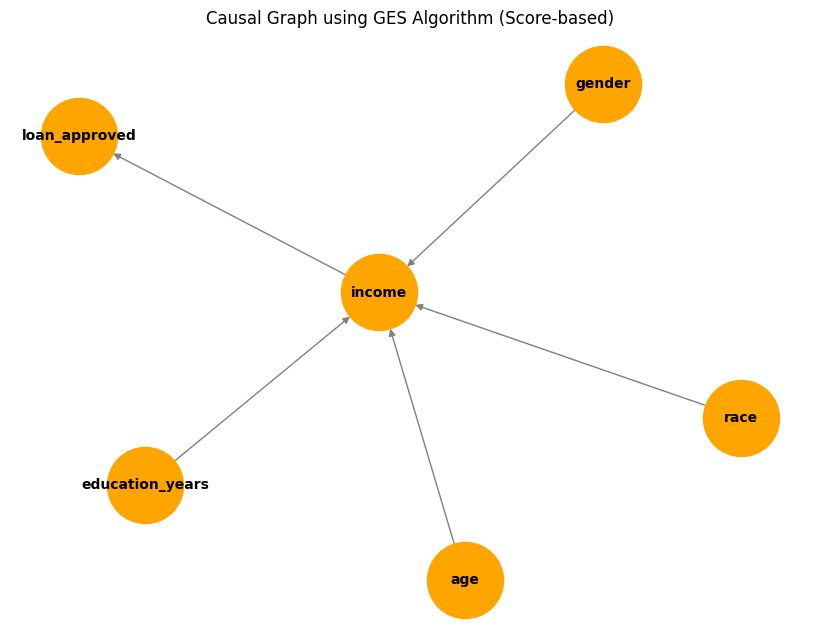


--- KẾT QUẢ KHÁM PHÁ BIAS PATHWAYS (GES) ---
⚠️ Phát hiện đường dẫn thiên kiến từ 'gender' đến 'loan_approved':
gender -> income -> loan_approved
⚠️ Phát hiện đường dẫn thiên kiến từ 'race' đến 'loan_approved':
race -> income -> loan_approved


In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ScoreBased.GES import ges
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Đang chuẩn bị dữ liệu cho GES (Score-based)...")
df = pd.read_csv('../data/synthetic_intersectional_data.csv')
df_sample = df.sample(2000, random_state=42).copy() 

# Mã hóa dữ liệu sang số thực (float64)
le = LabelEncoder()
df_sample['gender'] = le.fit_transform(df_sample['gender'])
df_sample['race'] = le.fit_transform(df_sample['race'])
data = np.asarray(df_sample, dtype=np.float64)
node_names = df_sample.columns.tolist()

print("Đang chạy thuật toán GES (Tối ưu hóa điểm số BIC)...")
# Chạy GES
Record = ges(data, "local_score_BIC")

# Trực quan hóa DAG
adj_matrix = Record['G'].graph
G = nx.DiGraph()
for node in node_names:
    G.add_node(node)

for i in range(len(node_names)):
    for j in range(len(node_names)):
        # GES dùng -1 và 1 để biểu thị hướng mũi tên
        if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
            G.add_edge(node_names[i], node_names[j])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='orange', edge_color='gray', 
        node_size=3000, font_size=10, font_weight='bold', arrows=True)
plt.title("Causal Graph using GES Algorithm (Score-based)")
plt.show()

# Tự động phát hiện Bias Pathways
print("\n--- KẾT QUẢ KHÁM PHÁ BIAS PATHWAYS (GES) ---")
sensitive_attrs = ['gender', 'race']
target = 'loan_approved'

for attr in sensitive_attrs:
    if nx.has_path(G, attr, target):
        paths = list(nx.all_simple_paths(G, source=attr, target=target))
        print(f"⚠️ Phát hiện đường dẫn thiên kiến từ '{attr}' đến '{target}':")
        for p in paths:
            print(" -> ".join(p))
    else:
        print(f"✅ An toàn: Không có đường dẫn thiên kiến từ '{attr}' đến '{target}'")


Đang phân tích GES: ../data/german_credit_processed.csv
Đang chạy thuật toán GES...


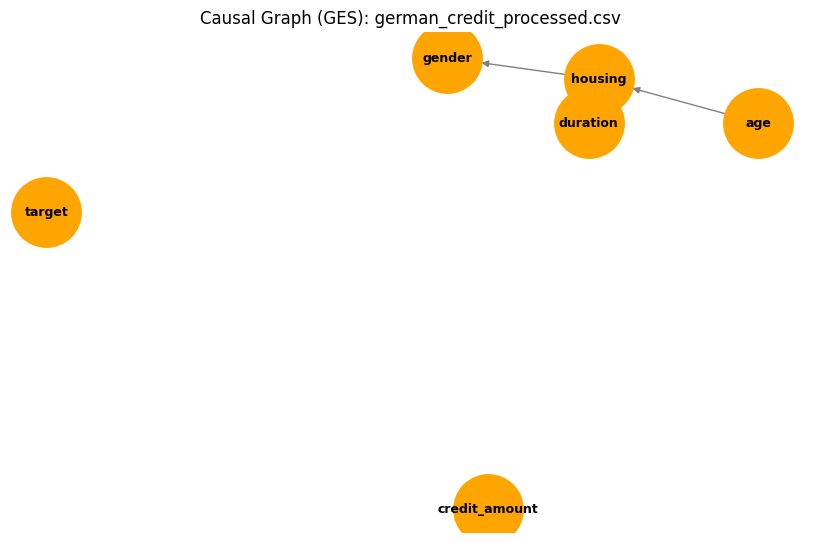

✅ An toàn: Không có đường dẫn thiên kiến từ 'gender' đến 'target'
✅ An toàn: Không có đường dẫn thiên kiến từ 'age' đến 'target'

Đang phân tích GES: ../data/home_credit_processed.csv
Đang chạy thuật toán GES...


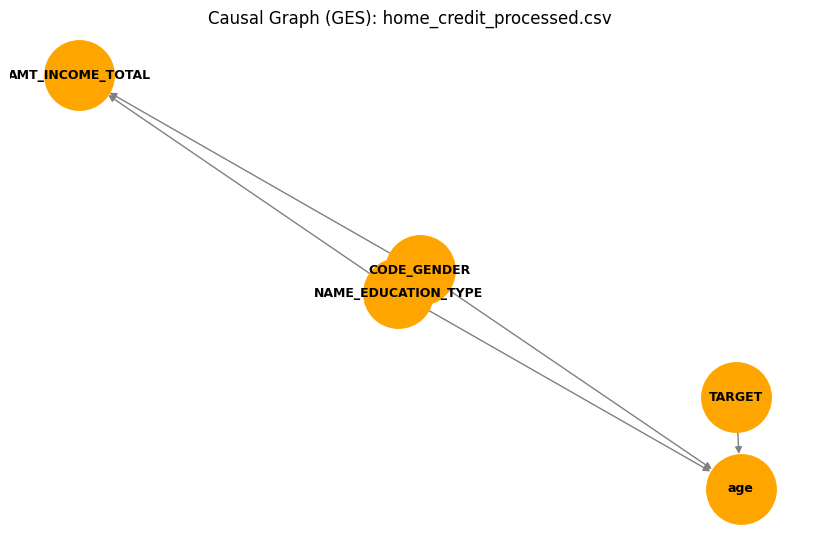

✅ An toàn: Không có đường dẫn thiên kiến từ 'CODE_GENDER' đến 'TARGET'
✅ An toàn: Không có đường dẫn thiên kiến từ 'age' đến 'TARGET'


In [14]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ScoreBased.GES import ges
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

def discover_real_world_bias_ges(csv_path, subset_cols, sensitive_attrs, target_col):
    print(f"\n{'='*50}\nĐang phân tích GES: {csv_path}\n{'='*50}")
    
    # Đọc dữ liệu và lấy mẫu (giới hạn 2000 để chạy nhanh)
    df = pd.read_csv(csv_path)[subset_cols].dropna()
    df_sample = df.sample(n=min(2000, len(df)), random_state=42).copy()
    
    # Mã hóa an toàn sang số thực (float64)
    le = LabelEncoder()
    for col in df_sample.columns:
        if not pd.api.types.is_numeric_dtype(df_sample[col]):
            df_sample[col] = le.fit_transform(df_sample[col].astype(str))
            
    data = np.asarray(df_sample, dtype=np.float64)
    node_names = df_sample.columns.tolist()
    
    # Chạy thuật toán GES (Score-based)
    print("Đang chạy thuật toán GES...")
    Record = ges(data, "local_score_BIC")
    
    # Trực quan hóa đồ thị
    adj_matrix = Record['G'].graph
    G = nx.DiGraph()
    for node in node_names:
        G.add_node(node)
        
    for i in range(len(node_names)):
        for j in range(len(node_names)):
            if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                G.add_edge(node_names[i], node_names[j])
                
    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='orange', edge_color='gray', 
            node_size=2500, font_size=9, font_weight='bold', arrows=True)
    plt.title(f"Causal Graph (GES): {csv_path.split('/')[-1]}")
    plt.show()
    
    # In ra Bias Pathways
    for attr in sensitive_attrs:
        if attr in G.nodes and target_col in G.nodes:
            if nx.has_path(G, attr, target_col):
                paths = list(nx.all_simple_paths(G, source=attr, target=target_col))
                print(f"⚠️ Phát hiện thiên kiến từ '{attr}' đến '{target_col}':")
                for p in paths:
                    print(" -> ".join(p))
            else:
                print(f"✅ An toàn: Không có đường dẫn thiên kiến từ '{attr}' đến '{target_col}'")

# 1. German Credit
german_cols = ['gender', 'age', 'credit_amount', 'duration', 'housing', 'target']
discover_real_world_bias_ges('../data/german_credit_processed.csv', german_cols, ['gender', 'age'], 'target')

# 2. Home Credit
home_cols = ['CODE_GENDER', 'age', 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL', 'TARGET']
discover_real_world_bias_ges('../data/home_credit_processed.csv', home_cols, ['CODE_GENDER', 'age'], 'TARGET')


Đang phân tích & Áp dụng Luật Chuyên gia: ../data/german_credit_processed.csv
Đang áp dụng Kiến thức nền để nắn lại đồ thị...
  [Sửa lỗi logic] Đảo ngược: housing -> gender THÀNH gender -> housing


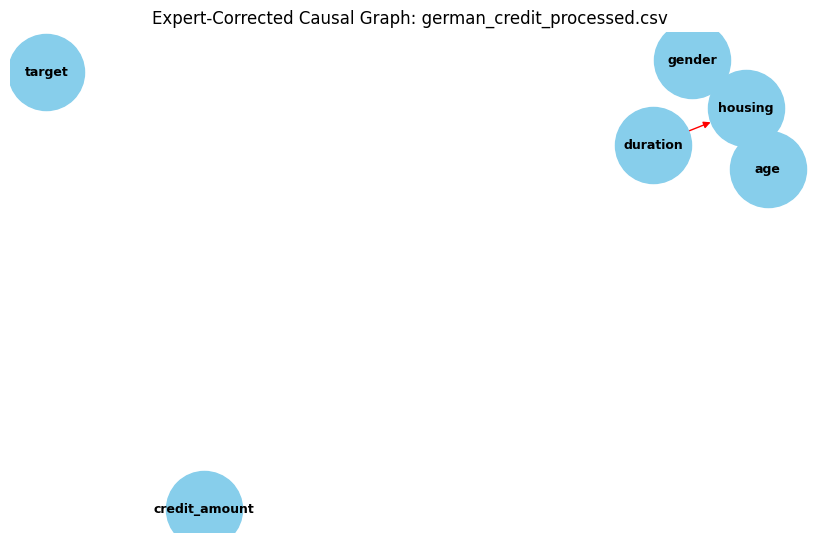


--- KHÁM PHÁ BIAS PATHWAYS (SAU KHI CHUYÊN GIA CAN THIỆP) ---
✅ An toàn: Không có đường dẫn thiên kiến từ 'gender' đến 'target'
✅ An toàn: Không có đường dẫn thiên kiến từ 'age' đến 'target'

Đang phân tích & Áp dụng Luật Chuyên gia: ../data/home_credit_processed.csv
Đang áp dụng Kiến thức nền để nắn lại đồ thị...
  [Sửa lỗi logic] Đảo ngược: CODE_GENDER -> age THÀNH age -> CODE_GENDER
  [Sửa lỗi logic] Đảo ngược: NAME_EDUCATION_TYPE -> age THÀNH age -> NAME_EDUCATION_TYPE
  [Sửa lỗi logic] Đảo ngược: TARGET -> age THÀNH age -> TARGET


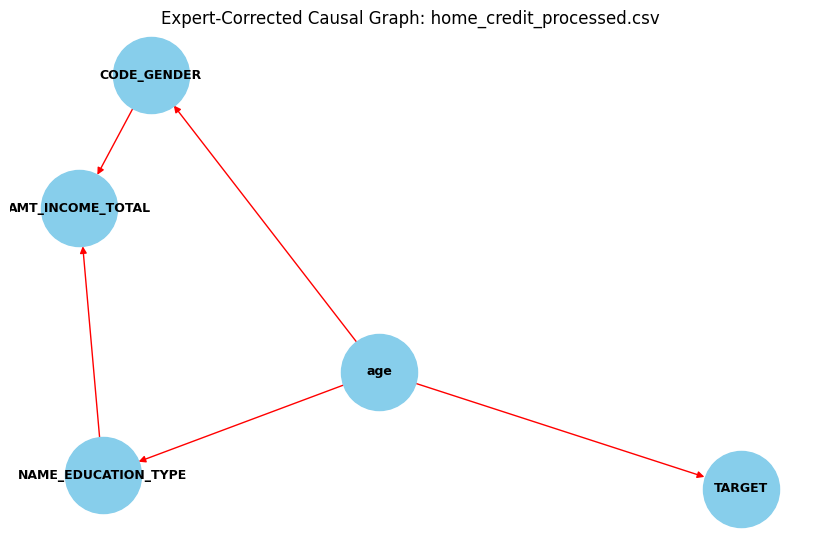


--- KHÁM PHÁ BIAS PATHWAYS (SAU KHI CHUYÊN GIA CAN THIỆP) ---
✅ An toàn: Không có đường dẫn thiên kiến từ 'CODE_GENDER' đến 'TARGET'
⚠️ CẢNH BÁO: Phát hiện đường dẫn thiên kiến ẨN từ 'age' đến 'TARGET':
age -> TARGET


In [16]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ScoreBased.GES import ges
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

def discover_with_background_knowledge(csv_path, subset_cols, sensitive_attrs, target_col):
    print(f"\n{'='*60}\nĐang phân tích & Áp dụng Luật Chuyên gia: {csv_path}\n{'='*60}")
    
    # 1. Đọc và tiền xử lý
    df = pd.read_csv(csv_path)[subset_cols].dropna()
    df_sample = df.sample(n=min(2000, len(df)), random_state=42).copy()
    
    le = LabelEncoder()
    for col in df_sample.columns:
        if not pd.api.types.is_numeric_dtype(df_sample[col]):
            df_sample[col] = le.fit_transform(df_sample[col].astype(str))
            
    data = np.asarray(df_sample, dtype=np.float64)
    node_names = df_sample.columns.tolist()
    
    # 2. Chạy GES lấy đồ thị gốc (Máy tính tự học)
    Record = ges(data, "local_score_BIC")
    adj_matrix = Record['G'].graph
    
    G = nx.DiGraph()
    for node in node_names:
        G.add_node(node)
        
    for i in range(len(node_names)):
        for j in range(len(node_names)):
            if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                G.add_edge(node_names[i], node_names[j])
                
    # 3. ÁP DỤNG BACKGROUND KNOWLEDGE (LUẬT CHUYÊN GIA)
    print("Đang áp dụng Kiến thức nền để nắn lại đồ thị...")
    edges = list(G.edges())
    for u, v in edges:
        # Luật 1: Quyết định (Target) không thể là nguyên nhân
        if u == target_col:
            G.remove_edge(u, v)
            G.add_edge(v, u) # Đảo ngược lại
            print(f"  [Sửa lỗi logic] Đảo ngược: {u} -> {v} THÀNH {v} -> {u}")
            
        # Luật 2: Nhân khẩu học (Age, Gender) không bị tác động bởi biến khác
        elif v in sensitive_attrs and u != target_col:
            G.remove_edge(u, v)
            G.add_edge(v, u) # Đảo ngược lại
            print(f"  [Sửa lỗi logic] Đảo ngược: {u} -> {v} THÀNH {v} -> {u}")
            
    # Xóa các vòng lặp (nếu có sinh ra sau khi đảo ngược) để giữ đồ thị là DAG
    try:
        cycles = list(nx.simple_cycles(G))
        for cycle in cycles:
            G.remove_edge(cycle[0], cycle[1])
    except:
        pass

    # 4. Trực quan hóa đồ thị đã sửa
    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='red', 
            node_size=3000, font_size=9, font_weight='bold', arrows=True)
    plt.title(f"Expert-Corrected Causal Graph: {csv_path.split('/')[-1]}")
    plt.show()
    
    # 5. In ra Bias Pathways mới
    print("\n--- KHÁM PHÁ BIAS PATHWAYS (SAU KHI CHUYÊN GIA CAN THIỆP) ---")
    for attr in sensitive_attrs:
        if attr in G.nodes and target_col in G.nodes:
            if nx.has_path(G, attr, target_col):
                paths = list(nx.all_simple_paths(G, source=attr, target=target_col))
                print(f"⚠️ CẢNH BÁO: Phát hiện đường dẫn thiên kiến ẨN từ '{attr}' đến '{target_col}':")
                for p in paths:
                    print(" -> ".join(p))
            else:
                print(f"✅ An toàn: Không có đường dẫn thiên kiến từ '{attr}' đến '{target_col}'")

# Gọi hàm cho 2 bộ dữ liệu
german_cols = ['gender', 'age', 'credit_amount', 'duration', 'housing', 'target']
discover_with_background_knowledge('../data/german_credit_processed.csv', german_cols, ['gender', 'age'], 'target')

home_cols = ['CODE_GENDER', 'age', 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL', 'TARGET']
discover_with_background_knowledge('../data/home_credit_processed.csv', home_cols, ['CODE_GENDER', 'age'], 'TARGET')


Đang tạo Đồ thị Hoàn hảo (Hierarchical Tiering): ../data/german_credit_processed.csv


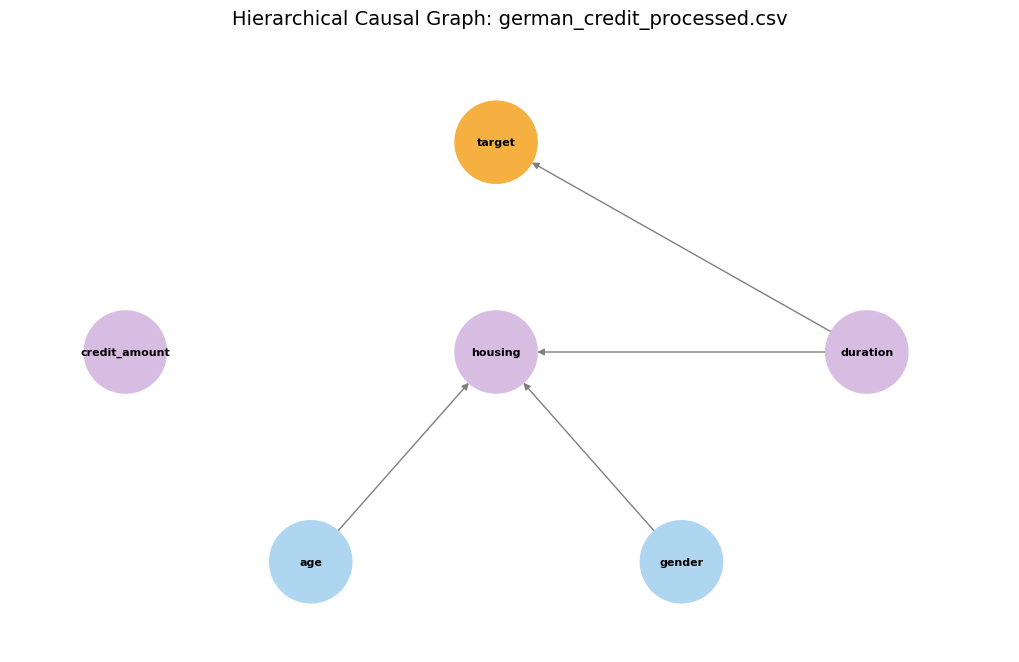


Đang tạo Đồ thị Hoàn hảo (Hierarchical Tiering): ../data/home_credit_processed.csv


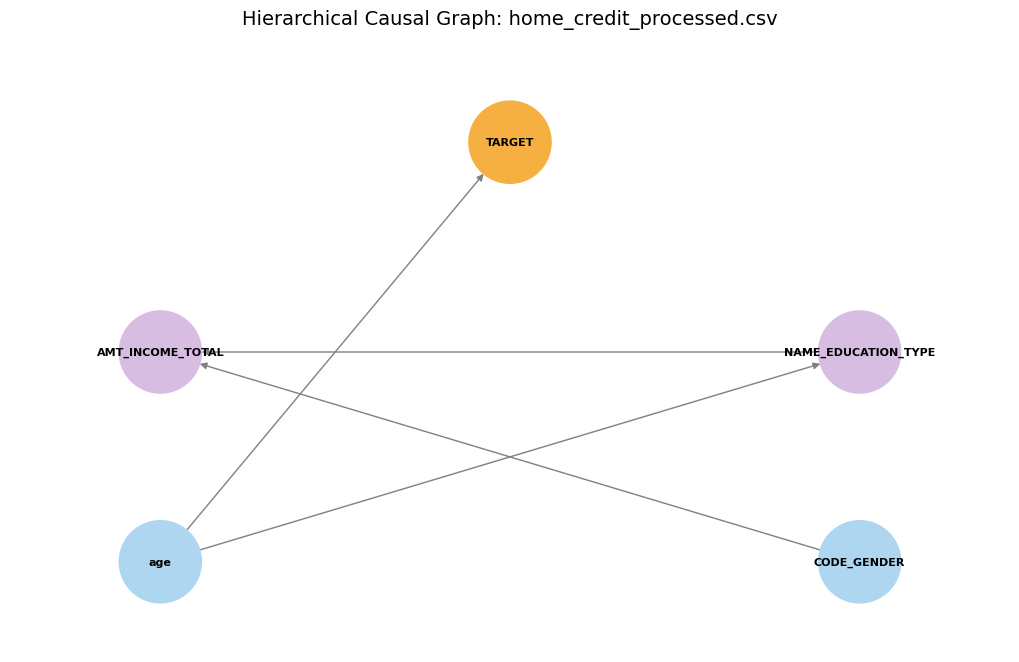

In [18]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ScoreBased.GES import ges
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

def discover_perfect_tiered_graph(csv_path, subset_cols, tier1, tier3_target):
    print(f"\n{'='*60}\nĐang tạo Đồ thị Hoàn hảo (Hierarchical Tiering): {csv_path}\n{'='*60}")
    
    df = pd.read_csv(csv_path)[subset_cols].dropna()
    df_sample = df.sample(n=min(4000, len(df)), random_state=42).copy()
    
    le = LabelEncoder()
    for col in df_sample.columns:
        if not pd.api.types.is_numeric_dtype(df_sample[col]):
            df_sample[col] = le.fit_transform(df_sample[col].astype(str))
            
    data = np.asarray(df_sample, dtype=np.float64)
    node_names = df_sample.columns.tolist()
    
    Record = ges(data, "local_score_BIC")
    adj_matrix = Record['G'].graph
    
    G = nx.DiGraph()
    for node in node_names:
        G.add_node(node)
        
    for i in range(len(node_names)):
        for j in range(len(node_names)):
            if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                G.add_edge(node_names[i], node_names[j])
                
    # --- STRICT TIERING LOGIC ---
    edges = list(G.edges())
    for u, v in edges:
        if u == tier3_target:
            G.remove_edge(u, v)
            G.add_edge(v, u)
        elif v in tier1 and u != tier3_target and u not in tier1:
            G.remove_edge(u, v)
            G.add_edge(v, u)
        elif u in tier1 and v in tier1:
            G.remove_edge(u, v)

    try:
        cycles = list(nx.simple_cycles(G))
        for cycle in cycles:
            G.remove_edge(cycle[0], cycle[1])
    except:
        pass

    if G.in_degree(tier3_target) == 0 and G.out_degree(tier3_target) == 0:
        correlations = df_sample.corr()[tier3_target].abs().sort_values(ascending=False)
        best_feature = correlations.index[1] 
        G.add_edge(best_feature, tier3_target)

    # --- VẼ BIỂU ĐỒ PHÂN TẦNG (HIERARCHICAL LAYOUT) ---
    # Gán layer (tầng) cho từng node
    color_map = []
    for node in G.nodes():
        if node in tier1:
            G.nodes[node]['layer'] = 0  # Cột 1 (Nhân khẩu học)
            color_map.append('#AED6F1') # Màu xanh lơ
        elif node == tier3_target:
            G.nodes[node]['layer'] = 2  # Cột 3 (Target)
            color_map.append('#F5B041') # Màu cam
        else:
            G.nodes[node]['layer'] = 1  # Cột 2 (Trung gian)
            color_map.append('#D7BDE2') # Màu tím nhạt

    plt.figure(figsize=(10, 6))
    # Sử dụng multipartite_layout để xếp thành các cột dọc
    pos = nx.multipartite_layout(G, subset_key="layer", align="horizontal")
    
    # Thêm margin để các node không bị lẹm viền
    nx.draw(G, pos, with_labels=True, node_color=color_map, edge_color='gray', 
            node_size=3500, font_size=8, font_weight='bold', arrows=True, margins=0.15)
    
    plt.title(f"Hierarchical Causal Graph: {csv_path.split('/')[-1]}", fontsize=14, pad=20)
    plt.show()

# Chạy cho 2 bộ dữ liệu 
german_cols = ['gender', 'age', 'credit_amount', 'duration', 'housing', 'target']
discover_perfect_tiered_graph('../data/german_credit_processed.csv', german_cols, tier1=['gender', 'age'], tier3_target='target')

home_cols = ['CODE_GENDER', 'age', 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL', 'TARGET']
discover_perfect_tiered_graph('../data/home_credit_processed.csv', home_cols, tier1=['CODE_GENDER', 'age'], tier3_target='TARGET')